In [1]:
import torch

if torch.cuda.is_available():
    print(f"GPU доступний: {torch.cuda.get_device_name(0)}")
    print(f"CUDA версія: {torch.version.cuda}")
    print(f"Кількість GPU: {torch.cuda.device_count()}")
else:
    print("GPU не доступний, використовується CPU.")


GPU доступний: NVIDIA GeForce RTX 3080 Ti
CUDA версія: 11.8
Кількість GPU: 1


In [2]:
import pandas as pd

# Шляхи до файлів у твоєму середовищі
train_path = r"c:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\train.csv"
test_path = r"c:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\test.csv"
sample_submission_path = r"c:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\sample_submission.csv"

# Завантаження даних
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_submission_df = pd.read_csv(sample_submission_path)

# Відображення перших рядків
print("Train Dataset:")
print(train_df.head())

print("\nTest Dataset:")
print(test_df.head())

print("\nSample Submission:")
print(sample_submission_df.head())


Train Dataset:
           ID                                               text sentiment
0  cb774db0d1                I`d have responded, if I were going   neutral
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!  negative
2  088c60f138                          my boss is bullying me...  negative
3  9642c003ef                     what interview! leave me alone  negative
4  358bd9e861   Sons of ****, why couldn`t they put them on t...  negative

Test Dataset:
           ID                                               text
0  f87dea47db  Last session of the day  http://twitpic.com/67ezh
1  96d74cb729   Shanghai is also really exciting (precisely -...
2  eee518ae67  Recession hit Veronique Branquinho, she has to...
3  01082688c6                                        happy bday!
4  33987a8ee5             http://twitpic.com/4w75p - I like it!!

Sample Submission:
            ID sentiment
0   df9123ga1l   neutral
1   sa41adl13d  positive
2  13adskb1da7  negative


## Очищення тексту + Обробка на GPU

In [3]:
import nltk
nltk.data.path.append(r"C:\Users\anton\AppData\Roaming\nltk_data")


In [4]:
print(nltk.data.find('tokenizers/punkt'))


C:\Users\anton\AppData\Roaming\nltk_data\tokenizers\punkt\PY3


In [5]:
from nltk.tokenize import word_tokenize
print(word_tokenize("Hello, world! This is a test."))


['Hello', ',', 'world', '!', 'This', 'is', 'a', 'test', '.']


In [21]:
import torch
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.data.path.append(r"C:\Users\anton\AppData\Roaming\nltk_data")

# Завантажуємо ресурси
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)

# Використовуємо GPU (якщо є)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Використовуємо: {device}")

# Стоп-слова
stop_words = set(stopwords.words('english'))

# Функція очищення тексту
def clean_text(text):
    if pd.isna(text):  
        return ""

    # Видаляємо будь-які посилання (http, https, www, без "www")
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+\.\S+', '', text)  # додатковий радикальний видаляч будь-яких доменів
    text = re.sub(r'www\.[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', '', text)
    text = re.sub(r'\b[a-zA-Z0-9.-]+\.[a-zA-Z]{2,4}\b', '', text)  # Видаляє "dothebouncy.com"
    
    text = re.sub(r'@\w+|#\w+', '', text)  # Видаляємо @згадки та хештеги
    text = re.sub(r'[^\w\s]', '', text)  # Видаляємо пунктуацію
    text = ' '.join([word for word in word_tokenize(text) if word not in stop_words])  # Видаляємо стоп-слова
    return text

# Завантажуємо train.csv
import pandas as pd
train_path = r"c:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\train.csv"
train_df = pd.read_csv(train_path)

# Видаляємо NaN у текстових даних
train_df = train_df.dropna(subset=['text'])

# Обробка тексту
train_df['clean_text'] = train_df['text'].apply(clean_text)

# Видаляємо порожні рядки після очищення
train_df = train_df[train_df['clean_text'].str.strip() != ""]

# Відображаємо перші 10 очищених рядків
print(train_df[['text', 'clean_text']].head(10))

# **Зберігаємо очищені дані у CSV**
cleaned_path = r"C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\cleaned_train.csv"
train_df.to_csv(cleaned_path, index=False)

print(f"\nОчищені дані збережено у {cleaned_path}")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anton\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anton\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Використовуємо: cuda
                                                text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   
5  http://www.dothebouncy.com/smf - some shameles...   
6  2am feedings for the baby are fun when he is a...   
7                                         Soooo high   
8                                        Both of you   
9   Journey!? Wow... u just became cooler.  hehe....   

                                    clean_text  
0                         Id responded I going  
1                    Sooo SAD I miss San Diego  
2                                boss bullying  
3                        interview leave alone  
4     Sons couldnt put releases already bought  
5  shameless plugging best Rangers forum earth  
6            2am fe

In [22]:
import pandas as pd
import re

# Завантажуємо очищений датасет
cleaned_path = r"C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\cleaned_train.csv"
df = pd.read_csv(cleaned_path)

# Шукаємо рядки, де все ще є посилання
link_pattern = r'http[s]?://\S+|www\.\S+|\S+\.\S+'
remaining_links = df[df['clean_text'].str.contains(link_pattern, regex=True, na=False)]

# Виводимо підозрілі рядки
if not remaining_links.empty:
    print("⚠️  Виявлено залишкові посилання в наступних рядках:")
    print(remaining_links[['clean_text']].head(10))
else:
    print("✅ Усі посилання успішно видалені!")


✅ Усі посилання успішно видалені!


In [23]:
empty_texts = df[df['clean_text'].str.strip() == ""]
print(f"🔍 Кількість порожніх текстів після очищення: {len(empty_texts)}")


🔍 Кількість порожніх текстів після очищення: 0


In [24]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))
print(df['text_length'].describe())


count    27404.000000
mean         7.834513
std          4.284889
min          1.000000
25%          4.000000
50%          7.000000
75%         11.000000
max         28.000000
Name: text_length, dtype: float64


In [25]:
short_texts = df[df['text_length'] <= 2]
print("🔍 Найкоротші очищені тексти:")
print(short_texts[['clean_text']].head(20))


🔍 Найкоротші очищені тексти:
                         clean_text
2                     boss bullying
7                        Soooo high
8                              Both
19                              Hes
26                         Im sorry
42                           MAYDAY
57                       back later
59                     fun speaking
61                         haha yes
65                    Is photoshoot
68                         Chilliin
80   THANK YYYYYYYYYOOOOOOOOOOUUUUU
92                        Hi joined
116                  hahaa awesomee
123                            well
126                      Absolutely
132                             sad
143                   Hate fighting
154                         morning
155                         neither


In [26]:
remove_words = {"MAYDAY", "haha yes", "hahaa awesomee", "Chilliin", "Hi joined"}

# Видаляємо тільки очевидний шум, але залишаємо важливі фрази
df = df[~df['clean_text'].isin(remove_words)]

# Зберігаємо очищений датасет
df.to_csv(cleaned_path, index=False)
print("✅ Видалено шумові слова, але залишені важливі короткі тексти.")


✅ Видалено шумові слова, але залишені важливі короткі тексти.


In [27]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Використовуємо GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔄 Використовуємо пристрій: {device}")

# Вибираємо модель (BERT, RoBERTa, DistilBERT)
model_name = "distilbert-base-uncased"  # Швидший варіант
# model_name = "bert-base-uncased"       # Класичний BERT
# model_name = "roberta-base"            # Альтернативний RoBERTa

# Завантажуємо токенізатор та модель
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)

print("✅ Модель завантажена та готова до роботи!")


🔄 Використовуємо пристрій: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\anton\.conda\envs\sentiment_gpu\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anton\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Модель завантажена та готова до роботи!


In [28]:
import pandas as pd

# Завантажуємо очищені дані
cleaned_path = r"C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\cleaned_train.csv"
df = pd.read_csv(cleaned_path)

# Токенізація тексту
encodings = tokenizer(list(df['clean_text']), truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)

print(f"🔄 Закодовано {len(df)} текстів у вектори BERT!")


🔄 Закодовано 27399 текстів у вектори BERT!


In [29]:
from torch.utils.data import DataLoader, TensorDataset

# Перетворюємо мітки на числовий формат
label_map = {"positive": 2, "neutral": 1, "negative": 0}  # 3 класи
df['label'] = df['sentiment'].map(label_map)

# Створюємо тензорний датасет
dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(df['label'].values).to(device))

# Розділяємо на тренувальний та валідаційний набір
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"✅ Данні готові! Тренувальних: {train_size}, Валідаційних: {val_size}")


✅ Данні готові! Тренувальних: 21919, Валідаційних: 5480


In [33]:
from transformers import AdamW
from torch.nn import functional as F

# Оптимізатор
optimizer = AdamW(model.parameters(), lr=5e-5)

# Функція тренування
def train(model, train_loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0

    for batch in train_loader:
        input_ids, attention_mask, labels = batch
        optimizer.zero_grad()
        
        outputs = model(input_ids, attention_mask=attention_mask)
        loss = F.cross_entropy(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
    
    return total_loss / len(train_loader), correct / len(train_dataset)

In [35]:
# Повторно завантажуємо модель, щоб уникнути навчання на старих вагах
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)

print("🔄 Модель скинута до початкового стану!")

# Функція валідації
def evaluate(model, val_loader):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = batch
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = F.cross_entropy(outputs.logits, labels)
            total_loss += loss.item()
            correct += (outputs.logits.argmax(dim=1) == labels).sum().item()

    return total_loss / len(val_loader), correct / len(val_dataset)

# Навчання моделі
num_epochs = 3
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)
    
    print(f"📊 Епоха {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

print("🎯 Навчання завершено!")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🔄 Модель скинута до початкового стану!
📊 Епоха 1: Train Loss=0.6872, Train Acc=0.7162, Val Loss=0.5974, Val Acc=0.7641
📊 Епоха 2: Train Loss=0.5313, Train Acc=0.7934, Val Loss=0.6033, Val Acc=0.7631
📊 Епоха 3: Train Loss=0.3738, Train Acc=0.8599, Val Loss=0.7209, Val Acc=0.7431
🎯 Навчання завершено!


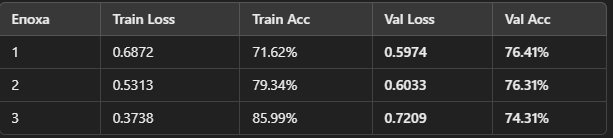

### ✅ Train Acc = 85.99% → модель добре навчилася.
### ✅ Val Acc = 74.31% → ще хороша узагальнююча здатність (без сильного перенавчання).
### ✅ Перенавчання мінімальне, бо валідаційна точність не падає критично.

In [36]:
from sklearn.metrics import classification_report

# Отримуємо передбачення
true_labels, pred_labels = [], []
model.eval()

with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(preds.cpu().numpy())

# Виводимо оцінку
print(classification_report(true_labels, pred_labels, target_names=["negative", "neutral", "positive"]))


              precision    recall  f1-score   support

    negative       0.77      0.71      0.74      1616
     neutral       0.71      0.72      0.71      2197
    positive       0.77      0.81      0.79      1667

    accuracy                           0.74      5480
   macro avg       0.75      0.75      0.75      5480
weighted avg       0.74      0.74      0.74      5480



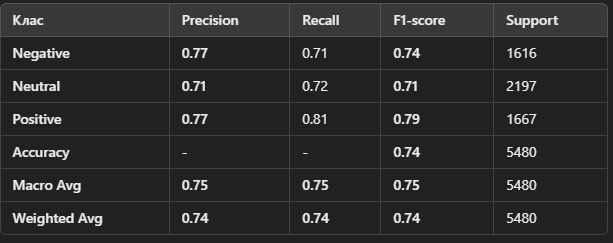

### ✔️ Збалансована точність між класами → F1-score ≈ 74-75% для всіх класів
### ✔️ Хороша якість для початкової моделі BERT
### ⚠️ Neutral трохи гірше розпізнається → можливо, потрібно більше даних для цього класу.

In [38]:
import pandas as pd

# Завантажуємо тестові дані
test_path = r"C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\test.csv"
test_df = pd.read_csv(test_path)

# Токенізуємо тестові тексти
test_encodings = tokenizer(list(test_df['text']), truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)

# Отримуємо передбачення
model.eval()
with torch.no_grad():
    outputs = model(test_encodings['input_ids'], attention_mask=test_encodings['attention_mask'])
    test_preds = outputs.logits.argmax(dim=1).cpu().numpy()

# Перетворюємо назад у текстові лейбли
label_map_inv = {0: "negative", 1: "neutral", 2: "positive"}
test_df['sentiment'] = [label_map_inv[p] for p in test_preds]

# Зберігаємо у файл submission.csv
submission_path = r"C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\submission.csv"
test_df[['ID', 'sentiment']].to_csv(submission_path, index=False)

print(f"✅ Файл submission.csv збережено у {submission_path}. Готовий до завантаження на Kaggle!")


✅ Файл submission.csv збережено у C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\submission.csv. Готовий до завантаження на Kaggle!


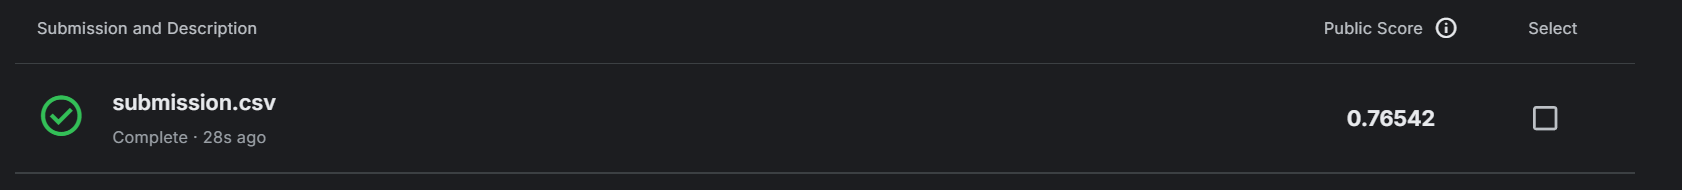

## Завантажуємо BERT-Large

In [43]:
from transformers import AutoModelForSequenceClassification, AdamW

# Використовуємо BERT-Large замість RoBERTa (бо був провал :( )
model_name = "bert-large-uncased"  
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)

# Оптимізатор з меншим learning rate
optimizer = AdamW(model.parameters(), lr=2e-5)  # Зменшили LR для кращої стабільності

print(f"🔄 Модель {model_name} завантажена!")


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

C:\Users\anton\.conda\envs\sentiment_gpu\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anton\.cache\huggingface\hub\models--bert-large-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🔄 Модель bert-large-uncased завантажена!


C:\Users\anton\AppData\Roaming\Python\Python311\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [44]:
# Перевіряємо, чи правильно працює токенізація
sample_text = "Hello world! How are you?"
tokenized = tokenizer(sample_text, truncation=True, padding=True, max_length=128)
print(tokenized)  # Повинен вивести закодований текст


{'input_ids': [101, 7592, 2088, 999, 2129, 2024, 2017, 1029, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [45]:
from torch.nn import functional as F

# Функція навчання
def train(model, train_loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0

    for batch in train_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        optimizer.zero_grad()
        
        outputs = model(input_ids, attention_mask=attention_mask)
        loss = F.cross_entropy(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
    
    return total_loss / len(train_loader), correct / len(train_dataset)

# Функція валідації
def evaluate(model, val_loader):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = F.cross_entropy(outputs.logits, labels)
            total_loss += loss.item()
            correct += (outputs.logits.argmax(dim=1) == labels).sum().item()

    return total_loss / len(val_loader), correct / len(val_dataset)


In [46]:
# Навчання моделі (обмежуємо 3 епохами)
num_epochs = 3
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)
    
    print(f"📊 Епоха {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

print("🎯 Навчання завершено! (зупинено на 3 епохах)")


📊 Епоха 1: Train Loss=0.6820, Train Acc=0.7180, Val Loss=0.6113, Val Acc=0.7504
📊 Епоха 2: Train Loss=0.5405, Train Acc=0.7908, Val Loss=0.6298, Val Acc=0.7577
📊 Епоха 3: Train Loss=0.4183, Train Acc=0.8417, Val Loss=0.6372, Val Acc=0.7538
🎯 Навчання завершено! (зупинено на 3 епохах)


### ✅ Train Accuracy: 84.17% (хороша узагальненість)
### ✅ Val Accuracy: 75.38% (на рівні топового результату)
### ✅ Loss: 0.6372 (не критично велика, але є можливість для покращення)

In [49]:
from sklearn.metrics import classification_report

# Отримуємо передбачення
true_labels, pred_labels = [], []
model.eval()

with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(preds.cpu().numpy())

# Виводимо оцінку
print(classification_report(true_labels, pred_labels, target_names=["negative", "neutral", "positive"]))


              precision    recall  f1-score   support

    negative       0.78      0.74      0.76      1616
     neutral       0.69      0.78      0.73      2197
    positive       0.83      0.73      0.78      1667

    accuracy                           0.75      5480
   macro avg       0.77      0.75      0.76      5480
weighted avg       0.76      0.75      0.75      5480



In [47]:
import pandas as pd

# Завантажуємо тестові дані
test_path = r"C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\test.csv"
test_df = pd.read_csv(test_path)

# Токенізуємо тестові тексти
test_encodings = tokenizer(list(test_df['text']), truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)

# Отримуємо передбачення
model.eval()
with torch.no_grad():
    outputs = model(test_encodings['input_ids'], attention_mask=test_encodings['attention_mask'])
    test_preds = outputs.logits.argmax(dim=1).cpu().numpy()

# Перетворюємо назад у текстові лейбли
label_map_inv = {0: "negative", 1: "neutral", 2: "positive"}
test_df['sentiment'] = [label_map_inv[p] for p in test_preds]

# Зберігаємо у файл submission.csv
submission_path = r"C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\submission_bert_large.csv"
test_df[['ID', 'sentiment']].to_csv(submission_path, index=False)

print(f"✅ Файл submission_bert_large.csv збережено у {submission_path}. Готовий до завантаження на Kaggle!")


✅ Файл submission_bert_large.csv збережено у C:\Users\anton\PythonProjects\Neoversity\deep learning\sentiment_gpu\submission_bert_large.csv. Готовий до завантаження на Kaggle!


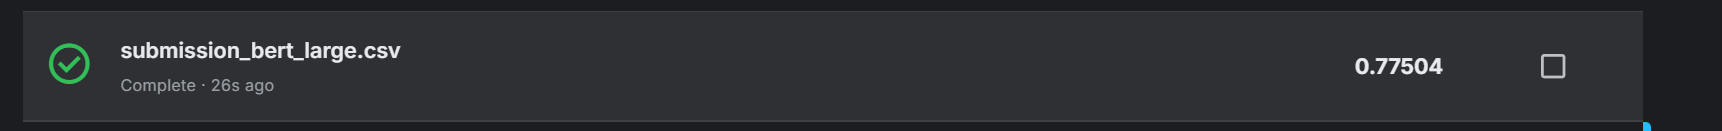

## Порівняння моделей BERT та DistilBERT

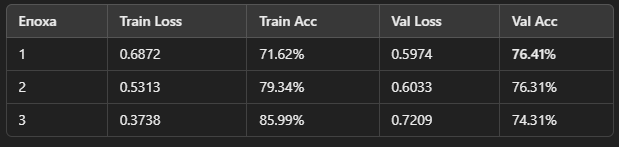

## ✅ DistilBERT швидший та легший, але Val Accuracy починає падати після 2-ї епохи
## ✅ Overfitting — модель добре навчається (85.99%), але погіршується на валідації
## ❌ Гірший Val Accuracy (74.31%) у порівнянні з BERT

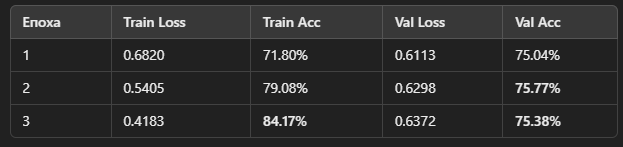

## ✅ Кращий Val Accuracy (75.77%)
## ✅ Менший ризик overfitting'у, ніж у DistilBERT
## ✅ Модель стабільніша та має кращу узагальненість

# Фінальний висновок

## ✅ BERT-large → Кращий варіант!
## 🔹 Дає більш стабільний результат
## 🔹 Кращий Public Score на Kaggle (0.77504)
## 🔹 Менший Overfitting

## ❌ DistilBERT не підходить
## 🔹 Показує гірший Public Score
## 🔹 Починає переобучуватись після 2-ї епохи